In [18]:
import math
# Define Box Parameters
# Let's divide the pitch into boxes
# Each box can be occupied by a max of 5 players

# define pitch 
Pitch_Length = 105 # meters
Pitch_Width = 68 # meters

# define our player size: player is a circle because we expect a player to occupy the same space in all orientations
player_radius = 0.3 #m 
player_area = math.pi * 0.3**2
box_len = 5 #m
box_wid = 4 #m
box_area = box_len * box_wid
# Number of boxes required to cover the pitch
count_len = Pitch_Length // box_len
count_wid = Pitch_Width // box_wid
num_boxes = count_len * count_wid

# How can players be stack in a box ? 
# In a realistic setting, when an attacker is being blocked by opposing players we assume that they do not intend
# to restrict each others movement. We can define this in terms of the distance a player needs to reach in order to complete a succesful tackle

leg_reach = 0.8          #m  # average length to which a player streaches their leg for an attack
ball_control_radius = 0.6 #m # how far ball may be from attacker

tackle_radius = leg_reach +  ball_control_radius + player_radius # length below which a tackle is possible

# Number of players in a box would typically mean, how many players and an attacker that can fit within a box
tackle_area = math.pi * tackle_radius**2
print(num_boxes)   
print(f"Tackle radius: {tackle_radius:.2f}m")

357
Tackle radius: 1.70m


In [1]:
# Let's Define a Football Pitch
import mplsoccer as football

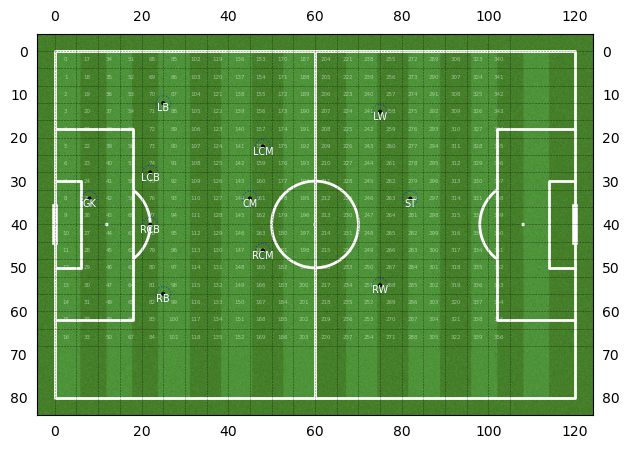

In [20]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

pitch = Pitch()
pitch = Pitch(pitch_color='grass', line_color='white', stripe=True,pitch_length=Pitch_Length, pitch_width=Pitch_Width,
              axis=True, label=True)

fig, ax = pitch.draw()

for x in range(0, Pitch_Length + 1, box_len):
    ax.axvline(x, color='black', linestyle='--', linewidth=0.4, alpha=0.5)

for y in range(0, Pitch_Width + 1, box_wid):
    ax.axhline(y, color='black', linestyle='--', linewidth=0.4, alpha=0.5)

# Optional: label cells
cell_id = 0
for i in range(count_len):
    for j in range(count_wid):
        cx = i * box_len + box_len / 2
        cy = j * box_wid + box_wid / 2

        ax.text(
            cx, cy, str(cell_id),
            ha='center',
            va='center',
            fontsize=4,
            color='white',
            alpha=0.5
        )

        cell_id += 1

# Basic 4-3-3 formation, attacking left to right
players_433 = [
    # Goalkeeper
    ("GK", 8, 34),

    # Back four
    ("LB", 25, 12),
    ("LCB", 22, 28),
    ("RCB", 22, 40),
    ("RB", 25, 56),

    # Midfield three
    ("LCM", 48, 22),
    ("CM", 45, 34),
    ("RCM", 48, 46),

    # Front three
    ("LW", 75, 14),
    ("ST", 82, 34),
    ("RW", 75, 54),
]

# Draw players
for name, x, y in players_433:
    body = Circle(
        (x, y),
        player_radius,
        edgecolor='black',
        facecolor='blue',
        linewidth=1,
        zorder=5
    )
    ax.add_patch(body)

    # Optional tackle/influence radius
    influence = Circle(
        (x, y),
        tackle_radius,
        edgecolor='blue',
        facecolor='none',
        linestyle=':',
        linewidth=0.8,
        alpha=0.5,
        zorder=4
    )
    ax.add_patch(influence)

    ax.text(
        x, y + 1.2, name,
        ha='center',
        va='center',
        fontsize=7,
        color='white',
        zorder=6
    )

